In [1]:
# ============================================
# CELL 1: INSTALL & IMPORT LIBRARIES
# ============================================

# Uncomment nếu bạn chưa cài đặt các thư viện cần thiết
# !pip install lightgbm pyarrow polars

import gc
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import timedelta
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# ============================================
# CELL 2: CONFIG
# ============================================

DATA_PATH = Path(r"/content/drive/MyDrive/Personal project/Paper/sales_train_evaluation.csv")
MAX_LAGS = 1912
LAST_D = 1913
HORIZON = 28

VALID_DATE = "2016-04-25"
TEST_DATE = "2016-03-28"

STATE = "CA"
FORECAST_DAYS = 28

LGB_PARAMS = {
    "objective": "tweedie",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "tweedie_variance_power": 1.2,
    "learning_rate": 0.075,
    "num_leaves": 2047,
    "min_data_in_leaf": 4095,
    "feature_fraction": 0.5,
    "subsample": 0.7,
    "subsample_freq": 1,
    "max_bin": 100,
    "verbosity": -1,
    "seed": 42
}

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# =================================================
# CELL 3: LOAD DATA (Đường dẫn chuẩn theo ảnh)
# =================================================

#calendar = pd.read_csv(r"/content/drive/MyDrive/Paper/calendar.csv")
#prices = pd.read_csv(r"/content/drive/MyDrive/Paper/sell_prices.csv")
#sales = pd.read_csv(r"/content/drive/MyDrive/Paper/sales_train_evaluation.csv")

calendar = pd.read_csv(r"/content/drive/MyDrive/Personal project/Paper/calendar.csv")
prices = pd.read_csv(r"/content/drive/MyDrive/Personal project/Paper/sell_prices.csv")
sales = pd.read_csv(r"/content/drive/MyDrive/Personal project/Paper/sales_train_evaluation.csv")

print("Calendar shape:", calendar.shape)
print("Prices shape:", prices.shape)
print("Sales shape:", sales.shape)

Calendar shape: (1969, 14)
Prices shape: (6841121, 4)
Sales shape: (30490, 1947)


In [5]:
# ============================================
# CELL 4: MEMORY REDUCTION
# ============================================

def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == "int":
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                else:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                else:
                    df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage().sum() / 1024**2
    print(f"Memory usage: {start_mem:.2f} MB -> {end_mem:.2f} MB")
    return df

calendar = reduce_mem_usage(calendar)
prices = reduce_mem_usage(prices)
sales = reduce_mem_usage(sales)

Memory usage: 0.21 MB -> 0.12 MB
Memory usage: 208.77 MB -> 130.48 MB
Memory usage: 452.91 MB -> 96.13 MB


In [6]:
# ============================================
# CELL 5: FILTER STORE
# ============================================

stores = {
    "CA": ["CA_1", "CA_2", "CA_3", "CA_4"],
    "TX": ["TX_1", "TX_2", "TX_3"],
    "WI": ["WI_1", "WI_2", "WI_3"]
}

STORE_ID = "CA_1"
sales_store = sales[sales["store_id"] == STORE_ID]
print("Filtered store shape:", sales_store.shape)

Filtered store shape: (3049, 1947)


In [7]:
# ============================================
# CELL 6: WIDE TO LONG
# ============================================

id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

sales_long = sales_store.melt(
    id_vars=id_cols,
    var_name="d",
    value_name="sales"
)

sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [8]:
# ============================================
# CELL 7: MERGE DATA
# ============================================

calendar["date"] = pd.to_datetime(calendar["date"])

sales_long = sales_long.merge(calendar, on="d", how="left")
sales_long = sales_long.merge(prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")

# Dọn dẹp RAM sau khi merge diện rộng
gc.collect()

sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN


In [9]:
# ============================================
# CELL 8: DATE FEATURES
# ============================================

sales_long["day"] = sales_long["date"].dt.day
sales_long["week"] = sales_long["date"].dt.isocalendar().week.astype(np.int32)
sales_long["month"] = sales_long["date"].dt.month
sales_long["year"] = sales_long["date"].dt.year
sales_long["weekday"] = sales_long["date"].dt.weekday

sales_long["is_weekend"] = (sales_long["weekday"] >= 5).astype(np.int8)

sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,day,week,is_weekend
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,NaN,0,0,0,NaN,29,4,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,NaN,0,0,0,NaN,29,4,1
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,NaN,0,0,0,NaN,29,4,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,NaN,0,0,0,NaN,29,4,1
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,NaN,0,0,0,NaN,29,4,1


In [10]:
# ============================================
# CELL 9: LAG FEATURES
# ============================================

# Sắp xếp theo id và date để đảm bảo lag shift chính xác theo dòng thời gian
sales_long = sales_long.sort_values(by=["id", "date"]).reset_index(drop=True)

LAGS = [7, 14, 28]
for lag in LAGS:
    sales_long[f"lag_{lag}"] = sales_long.groupby("id")["sales"].shift(lag)

sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,snap_CA,snap_TX,snap_WI,sell_price,day,week,is_weekend,lag_7,lag_14,lag_28
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,...,0,0,0,2.0,29,4,1,NaN,NaN,NaN
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,...,0,0,0,2.0,30,4,1,NaN,NaN,NaN
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,...,0,0,0,2.0,31,5,0,NaN,NaN,NaN
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,...,1,1,0,2.0,1,5,0,NaN,NaN,NaN
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,...,1,0,1,2.0,2,5,0,NaN,NaN,NaN


In [11]:
# ============================================
# CELL 10: ROLLING FEATURES
# ============================================

WINDOWS = [7, 14, 28]
for window in WINDOWS:
    # shift(28) tránh rò rỉ dữ liệu (data leakage) khi dự báo chu kỳ 28 ngày
    sales_long[f"rmean_{window}"] = (
        sales_long.groupby("id")["sales"]
        .transform(lambda x: x.shift(28).rolling(window).mean())
    )
    sales_long[f"rstd_{window}"] = (
        sales_long.groupby("id")["sales"]
        .transform(lambda x: x.shift(28).rolling(window).std())
    )

sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,is_weekend,lag_7,lag_14,lag_28,rmean_7,rstd_7,rmean_14,rstd_14,rmean_28,rstd_28
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# ============================================
# CELL 11: PRICE FEATURES
# ============================================

sales_long["price_change"] = sales_long.groupby("id")["sell_price"].pct_change()
sales_long["price_max"] = sales_long.groupby("id")["sell_price"].transform("max")
sales_long["price_norm"] = sales_long["sell_price"] / sales_long["price_max"]

sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,lag_28,rmean_7,rstd_7,rmean_14,rstd_14,rmean_28,rstd_28,price_change,price_max,price_norm
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.240234,0.892578
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.240234,0.892578
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.240234,0.892578
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.240234,0.892578
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.240234,0.892578


In [13]:
# ============================================
# CELL 12: ENCODING
# ============================================

from sklearn.preprocessing import LabelEncoder

cat_cols = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2",
]

for col in cat_cols:
    # Fill NaN with a placeholder string to ensure LabelEncoder can process it
    # and then apply Label Encoding to convert strings to unique integers
    sales_long[col] = sales_long[col].fillna("NoEvent")
    le = LabelEncoder()
    sales_long[col] = le.fit_transform(sales_long[col])

# Additionally, fill NaNs for numerical features that might have been introduced
# by lag, rolling, or price feature engineering. Filling with 0 is a common strategy.
numerical_cols_with_nans = [
    'sell_price', 'price_change', 'price_max', 'price_norm',
    'lag_7', 'lag_14', 'lag_28',
    'rmean_7', 'rstd_7', 'rmean_14', 'rstd_14', 'rmean_28', 'rstd_28'
]

for col in numerical_cols_with_nans:
    if col in sales_long.columns:
        sales_long[col] = sales_long[col].fillna(0) # Filling with 0

sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,lag_28,rmean_7,rstd_7,rmean_14,rstd_14,rmean_28,rstd_28,price_change,price_max,price_norm
0,FOODS_1_001_CA_1_evaluation,0,0,0,0,0,d_1,3,2011-01-29,11101,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.240234,0.892578
1,FOODS_1_001_CA_1_evaluation,0,0,0,0,0,d_2,0,2011-01-30,11101,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.240234,0.892578
2,FOODS_1_001_CA_1_evaluation,0,0,0,0,0,d_3,0,2011-01-31,11101,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.240234,0.892578
3,FOODS_1_001_CA_1_evaluation,0,0,0,0,0,d_4,1,2011-02-01,11101,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.240234,0.892578
4,FOODS_1_001_CA_1_evaluation,0,0,0,0,0,d_5,4,2011-02-02,11101,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.240234,0.892578


In [14]:
# ============================================
# CELL 13: TRAIN VALID SPLIT
# ============================================

# Đảm bảo định dạng datetime đồng nhất để lọc dữ liệu chính xác
train_data = sales_long[sales_long["date"] < pd.to_datetime(TEST_DATE)]
valid_data = sales_long[(sales_long["date"] >= pd.to_datetime(TEST_DATE)) & (sales_long["date"] < pd.to_datetime(VALID_DATE))]

FEATURES = [
    col for col in sales_long.columns
    if col not in ["sales", "date", "d", "id"]
]

X_train = train_data[FEATURES]
y_train = train_data["sales"]

X_valid = valid_data[FEATURES]
y_valid = valid_data["sales"]

problematic_cat_cols = [col for col in ["event_name_1", "event_type_1", "event_name_2", "event_type_2"] if col in FEATURES]
for col in problematic_cat_cols:
    X_train[col] = X_train[col].astype(np.int32)
    X_valid[col] = X_valid[col].astype(np.int32)

print("Train shape:", X_train.shape)
print("Validation shape:", X_valid.shape)

Train shape: (5747365, 33)
Validation shape: (85372, 33)


In [15]:
# ============================================
# TRAIN XGBOOST
# ============================================

import xgboost as xgb
from sklearn.metrics import mean_squared_error

# Chuyển dữ liệu sang DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_valid, label=y_valid)

# Parameters
XGB_PARAMS = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "learning_rate": 0.05,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42
}

# Train
model = xgb.train(
    params=XGB_PARAMS,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=[
        (dtrain, "train"),
        (dvalid, "valid")
    ],
    early_stopping_rounds=100,
    verbose_eval=100
)

[0]	train-rmse:3.94526	valid-rmse:3.37250
[100]	train-rmse:2.22799	valid-rmse:2.11032
[200]	train-rmse:2.17002	valid-rmse:2.11154
[256]	train-rmse:2.14100	valid-rmse:2.11747


In [16]:
import numpy as np
from sklearn.metrics import mean_squared_error

# ============================================
# CELL 15: VALIDATION PREDICTION
# ============================================

preds = model.predict(dvalid)

rmse = np.sqrt(mean_squared_error(y_valid, preds))
print("Validation RMSE:", rmse)

Validation RMSE: 2.11747216144444


In [17]:
import pickle

# Save XGBoost model
model.save_model("xgb_model.json")

# Save SHAP data
with open("shap_data.pkl", "wb") as f:
    pickle.dump({
        "X_valid": X_valid,
        "valid_data": valid_data[["id", "item_id", "dept_id", "cat_id", "date"]],
        "FEATURES": FEATURES
    }, f)

print("✅ Saved xgb_model.json + shap_data.pkl")

✅ Saved xgb_model.json + shap_data.pkl


In [18]:
# ============================================
# SAVE XGBOOST MODEL + SHAP DATA TO GOOGLE DRIVE
# ============================================

from google.colab import drive
import os
import pickle

# Mount Google Drive
drive.mount('/content/drive')

# Folder lưu kết quả
SAVE_DIR = "/content/drive/MyDrive/Personal project/Paper"
os.makedirs(SAVE_DIR, exist_ok=True)

# File paths
MODEL_PATH = os.path.join(SAVE_DIR, "xgb_model.json")
SHAP_PATH = os.path.join(SAVE_DIR, "shap_data.pkl")

# ============================================
# SAVE XGBOOST MODEL
# ============================================

try:
    model.save_model(MODEL_PATH)
    print(f"✅ XGBoost model saved to:")
    print(MODEL_PATH)

except Exception as e:
    print(f"❌ Error saving XGBoost model: {e}")

# ============================================
# SAVE SHAP DATA
# ============================================

try:
    with open(SHAP_PATH, "wb") as f:
        pickle.dump(
            {
                "X_valid": X_valid,
                "valid_data": valid_data[
                    ["id", "item_id", "dept_id", "cat_id", "date"]
                ],
                "FEATURES": FEATURES
            },
            f
        )

    print(f"✅ SHAP data saved to:")
    print(SHAP_PATH)

except Exception as e:
    print(f"❌ Error saving SHAP data: {e}")

print("\n🎉 Saving process completed!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ XGBoost model saved to:
/content/drive/MyDrive/Personal project/Paper/xgb_model.json
✅ SHAP data saved to:
/content/drive/MyDrive/Personal project/Paper/shap_data.pkl

🎉 Saving process completed!


In [19]:
import os

print(os.path.exists("xgb_model.json"))  # phải ra True
print(os.path.exists("shap_data.pkl"))   # phải ra True

True
True


In [20]:
# ============================================
# CELL 16: FEATURE IMPORTANCE
# ============================================

importance_dict = model.get_score(importance_type='gain')

importance = pd.DataFrame({
    "feature": list(importance_dict.keys()),
    "importance": list(importance_dict.values())
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance.head(30)

,feature,importance
26,rmean_28,62253.312500
19,lag_7,56845.835938
24,rmean_14,33939.375000
20,lag_14,15919.227539
22,rmean_7,15717.833984
21,lag_28,4532.094238
29,price_max,4180.441895
28,price_change,4094.594238
30,price_norm,4082.646729
15,sell_price,2969.205322


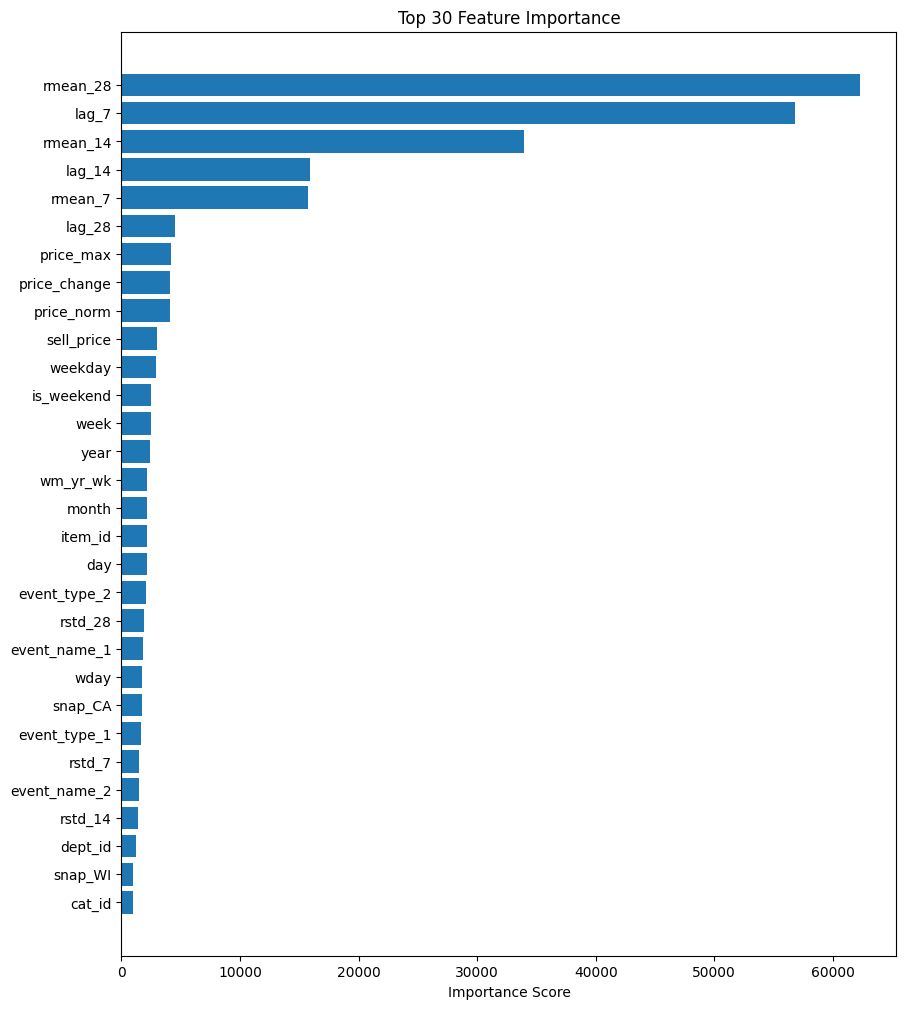

In [21]:
# ============================================
# CELL 17: PLOT IMPORTANCE
# ============================================

top_imp = importance.head(30)

plt.figure(figsize=(10, 12))
plt.barh(top_imp["feature"], top_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Top 30 Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
import xgboost as xgb
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
import pandas as pd # Explicitly import pandas
import numpy as np # Explicitly import numpy
from pathlib import Path # Explicitly import Path
import gc # For garbage collection

# ============================================
# RE-DEFINING CONSTANTS AND HELPER FUNCTION FOR ROBUSTNESS
# ============================================
# These are typically defined in earlier cells but are needed for sales_store
DATA_PATH = Path(r"/content/drive/MyDrive/Personal project/Paper/sales_train_evaluation.csv")
VALID_DATE = "2016-04-25"
STORE_ID = "CA_1"
LAGS = [7, 14, 28] # Defined in CELL 9
WINDOWS = [7, 14, 28] # Defined in CELL 10

def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == "int":
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                else:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                else:
                    df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage().sum() / 1024**2
    # print(f"Memory usage: {start_mem:.2f} MB -> {end_mem:.2f} MB") # Suppress output
    return df

# ============================================n
# RE-LOADING AND FILTERING DATA FOR ROBUSTNESS
# ============================================
# These are typically loaded and processed in earlier cells
calendar = pd.read_csv(r"/content/drive/MyDrive/Personal project/Paper/calendar.csv")
prices = pd.read_csv(r"/content/drive/MyDrive/Personal project/Paper/sell_prices.csv")
sales = pd.read_csv(r"/content/drive/MyDrive/Personal project/Paper/sales_train_evaluation.csv")

calendar = reduce_mem_usage(calendar)
prices = reduce_mem_usage(prices)
sales = reduce_mem_usage(sales)

sales_store = sales[sales["store_id"] == STORE_ID]

# ============================================
# WIDE TO LONG (from CELL 6)
# ============================================

id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

sales_long = sales_store.melt(
    id_vars=id_cols,
    var_name="d",
    value_name="sales"
)

# ============================================
# MERGE DATA (from CELL 7)
# ============================================

calendar["date"] = pd.to_datetime(calendar["date"])

sales_long = sales_long.merge(calendar, on="d", how="left")
sales_long = sales_long.merge(prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")

gc.collect()

# ============================================
# DATE FEATURES (from CELL 8)
# ============================================

sales_long["day"] = sales_long["date"].dt.day
sales_long["week"] = sales_long["date"].dt.isocalendar().week.astype(np.int32)
sales_long["month"] = sales_long["date"].dt.month
sales_long["year"] = sales_long["date"].dt.year
sales_long["weekday"] = sales_long["date"].dt.weekday

sales_long["is_weekend"] = (sales_long["weekday"] >= 5).astype(np.int8)

# ============================================
# LAG FEATURES (from CELL 9)
# ============================================

sales_long = sales_long.sort_values(by=["id", "date"]).reset_index(drop=True)

for lag in LAGS:
    sales_long[f"lag_{lag}"] = sales_long.groupby("id")["sales"].shift(lag)

# ============================================
# ROLLING FEATURES (from CELL 10)
# ============================================

for window in WINDOWS:
    sales_long[f"rmean_{window}"] = (
        sales_long.groupby("id")["sales"]
        .transform(lambda x: x.shift(28).rolling(window).mean())
    )
    sales_long[f"rstd_{window}"] = (
        sales_long.groupby("id")["sales"]
        .transform(lambda x: x.shift(28).rolling(window).std())
    )

# ============================================
# PRICE FEATURES (from CELL 11)
# ============================================

sales_long["price_change"] = sales_long.groupby("id")["sell_price"].pct_change()
sales_long["price_max"] = sales_long.groupby("id")["sell_price"].transform("max")
sales_long["price_norm"] = sales_long["sell_price"] / sales_long["price_max"]

# ============================================
# FILL NUMERICAL NANS (from CELL 12)
# ============================================

numerical_cols_with_nans = [
    'sell_price', 'price_change', 'price_max', 'price_norm',
    'lag_7', 'lag_14', 'lag_28',
    'rmean_7', 'rstd_7', 'rmean_14', 'rstd_14', 'rmean_28', 'rstd_28'
]

for col in numerical_cols_with_nans:
    if col in sales_long.columns:
        sales_long[col] = sales_long[col].fillna(0) # Filling with 0


# Reconstruct label_encoders and then encode sales_long
label_encoders = {}
cat_cols = [
    "item_id", "dept_id", "cat_id", "store_id", "state_id",
    "event_name_1", "event_type_1", "event_name_2", "event_type_2",
]

# Collect all unique categories from sales_store and calendar, including "NoEvent"
# This ensures the encoders are fitted on the complete set of possible values.
all_item_ids = sales_store["item_id"].unique()
all_dept_ids = sales_store["dept_id"].unique()
all_cat_ids = sales_store["cat_id"].unique()
all_store_ids = sales_store["store_id"].unique() # Use sales_store['store_id'] to get store id list, not 'store'
all_state_ids = sales_store["state_id"].unique()

all_event_name_1 = calendar["event_name_1"].unique()
all_event_type_1 = calendar["event_type_1"].unique()
all_event_name_2 = calendar["event_name_2"].unique()
all_event_type_2 = calendar["event_type_2"].unique()

# Consolidated mapping for category retrieval
category_sources = {
    "item_id": all_item_ids,
    "dept_id": all_dept_ids,
    "cat_id": all_cat_ids,
    "store_id": all_store_ids,
    "state_id": all_state_ids,
    "event_name_1": all_event_name_1,
    "event_type_1": all_event_type_1,
    "event_name_2": all_event_name_2,
    "event_type_2": all_event_type_2,
}

for col in cat_cols:
    le = LabelEncoder()
    # Convert all categories to string before fitting to handle NaNs and ensure consistency.
    all_categories_for_col = np.append(category_sources[col].astype(str), ["NoEvent"])
    le.fit(all_categories_for_col)
    label_encoders[col] = le

    # APPLY this fitted encoder to sales_long's categorical columns
    sales_long[col] = sales_long[col].fillna("NoEvent").astype(str) # Ensure string for encoder
    sales_long[col] = le.transform(sales_long[col])
    sales_long[col] = sales_long[col].astype(np.int32) # Convert to int32 for consistency

# Historical data
full_df = sales_long.copy() # Now sales_long has encoded categorical columns

# Future dates
future_dates = pd.date_range(
    start=VALID_DATE,
    periods=28
)

# ============================================
# CREATE FUTURE ROWS
# ============================================

unique_ids = full_df["id"].unique()

future_forecast_rows = pd.DataFrame({
    "id": np.repeat(unique_ids, len(future_dates)),
    "date": np.tile(future_dates, len(unique_ids))
})

# Metadata
meta_cols = [
    "id",
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]

future_forecast_rows = future_forecast_rows.merge(
    sales_store[meta_cols].drop_duplicates("id"),
    on="id",
    how="left"
)

# Calendar features
calendar_cols = [
    "date",
    "d",
    "wm_yr_wk",
    "weekday",
    "wday",
    "month",
    "year",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2",
    "snap_CA",
    "snap_TX",
    "snap_WI"
]

calendar["date"] = pd.to_datetime(calendar["date"])

future_forecast_rows = future_forecast_rows.merge(
    calendar[calendar_cols],
    on="date",
    how="left"
)

# Weekday
future_forecast_rows["weekday"] = (
    future_forecast_rows["date"]
    .dt.weekday
)

# Price
future_forecast_rows = future_forecast_rows.merge(
    prices[
        [
            "store_id",
            "item_id",
            "wm_yr_wk",
            "sell_price"
        ]
    ],
    on=[
        "store_id",
        "item_id",
        "wm_yr_wk"
    ],
    how="left"
)

# Date features
future_forecast_rows["day"] = (
    future_forecast_rows["date"].dt.day
)

future_forecast_rows["week"] = (
    future_forecast_rows["date"]
    .dt.isocalendar()
    .week
    .astype(np.int32)
)

future_forecast_rows["is_weekend"] = (
    future_forecast_rows["weekday"] >= 5
).astype(np.int8)

# Price features
future_forecast_rows["price_change"] = (
    future_forecast_rows
    .groupby("id")["sell_price"]
    .pct_change()
)

future_forecast_rows["price_max"] = (
    future_forecast_rows
    .groupby("id")["sell_price"]
    .transform("max")
)

future_forecast_rows["price_norm"] = (
    future_forecast_rows["sell_price"]
    / future_forecast_rows["price_max"]
)

# Placeholder
future_forecast_rows["sales"] = np.nan

# ============================================
# IMPORTANT:
# USE SAME ENCODING AS TRAINING
# ============================================

for col in [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2"
]:
    if col in future_forecast_rows.columns:

        future_forecast_rows[col] = (
            future_forecast_rows[col]
            .fillna("NoEvent")
        )

        # MUST use encoder from training
        future_forecast_rows[col] = (
            label_encoders[col]
            .transform(
                future_forecast_rows[col]
                .astype(str)
            )
        )

        future_forecast_rows[col] = (
            future_forecast_rows[col]
            .astype(np.int32)
        )

# ============================================
# COMBINE DATA
# ============================================

full_df = pd.concat(
    [full_df, future_forecast_rows],
    ignore_index=True
)

full_df = (
    full_df
    .sort_values(["id", "date"])
    .reset_index(drop=True)
)

# ============================================n
# LOAD THE TRAINED XGBOOST MODEL
# ============================================
# The model was saved to 'xgb_model.json' in an earlier cell.
# We need to load it back to use for prediction.
MODEL_PATH = "/content/drive/MyDrive/Personal project/Paper/xgb_model.json" # Ensure this path is correct
model = xgb.Booster() # Initialize a Booster model
model.load_model(MODEL_PATH) # Load the trained model

# ============================================
# RECURSIVE FORECAST
# ============================================

predictions = []

fill_cols = [
    "sell_price",
    "price_change",
    "price_max",
    "price_norm",
    "lag_7",
    "lag_14",
    "lag_28",
    "rmean_7",
    "rstd_7",
    "rmean_14",
    "rstd_14",
    "rmean_28",
    "rstd_28"
]

# Assuming FEATURES, model are defined globally or in previous cells
# FEATURES should be defined based on the full set of features after all preprocessing
FEATURES = [
    col for col in sales_long.columns
    if col not in ["sales", "date", "d", "id"]
] # Re-defining FEATURES based on the now complete sales_long

for current_day in tqdm(
    future_dates,
    desc="Forecasting"
):

    # Lag features
    for lag in LAGS:

        full_df[f"lag_{lag}"] = (
            full_df
            .groupby("id")["sales"]
            .shift(lag)
        )

    # Rolling features
    for window in WINDOWS:

        full_df[f"rmean_{window}"] = (
            full_df.groupby("id")["sales"]
            .transform(
                lambda x:
                x.shift(28)
                .rolling(window)
                .mean()
            )
        )

        full_df[f"rstd_{window}"] = (
            full_df.groupby("id")["sales"]
            .transform(
                lambda x:
                x.shift(28)
                .rolling(window)
                .std()
            )
        )

    day_mask = (
        full_df["date"] == current_day
    )

    X_day = (
        full_df.loc[
            day_mask,
            FEATURES
        ]
        .copy()
    )

    # Fill missing values
    for col in fill_cols:

        if col in X_day.columns:

            X_day[col] = (
                X_day[col]
                .fillna(0)
                .astype(np.float32)
            )

    # Convert categorical columns to 'category' dtype for XGBoost
    for col in cat_cols:
        if col in X_day.columns:
            # Ensure the column exists and is not already of numeric type where category is not appropriate
            if X_day[col].dtype == np.int32: # Only convert if it's the integer encoded type
                X_day[col] = X_day[col].astype('category')

    # XGBoost prediction
    dday = xgb.DMatrix(X_day, enable_categorical=True)

    day_preds = model.predict(dday)

    # Save prediction
    full_df.loc[
        day_mask,
        "sales"
    ] = day_preds

    predictions.extend(day_preds)

print("✅ Forecast completed.")

In [ ]:
predicted_demand_df = full_df[full_df['date'] >= pd.to_datetime(VALID_DATE)]

# Chỉ lấy các cột cần thiết như ID, Ngày, và Doanh số dự báo
predicted_demand_df = predicted_demand_df[['id', 'date', 'sales']]

# Đổi tên cột 'sales' thành 'predicted_demand' cho rõ ràng
predicted_demand_df.rename(columns={'sales': 'predicted_demand'}, inplace=True)

# Xuất ra file
predicted_demand_df.to_csv('predicted_demand1.csv', index=False)

In [ ]:
predicted_demand_df = predicted_demand_df[['id', 'date', 'predicted_demand']]
# ============================================
# CELL 20: DEMAND SUMMARY FOR AGENT
# ============================================

agent_demand = (
    predicted_demand_df
    .groupby("id")
    .agg(
        total_forecast_demand=(
            "predicted_demand",
            "sum"
        ),
        avg_daily_demand=(
            "predicted_demand",
            "mean"
        ),
        max_daily_demand=(
            "predicted_demand",
            "max"
        ),
        demand_std=(
            "predicted_demand",
            "std"
        )
    )
    .reset_index()
)

agent_demand["demand_std"] = (
    agent_demand["demand_std"]
    .fillna(0)
)

print(agent_demand.head())

agent_demand.to_csv(
    "agent_demand_summary.csv",
    index=False
)

In [ ]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import xgboost as xgb
import pandas as pd # Ensure pandas is imported for date operations

# Re-define constants and features if not available (assuming prior cells were run)
# These values are taken from CELL 2 (O2pvfeRm4-N4) and CELL 13 (dbC0rkLS5Lxj)
# to ensure robustness in this evaluation cell.
TEST_DATE = "2016-03-28"
VALID_DATE = "2016-04-25"

# The model path is defined in CELL 19 (Jq8Y5n4a5Sij) where the model is saved/loaded.
MODEL_PATH = "/content/drive/MyDrive/Personal project/Paper/xgb_model.json"

# Load the trained XGBoost model if not already loaded
if 'model' not in locals() and 'model' not in globals():
    model = xgb.Booster()
    model.load_model(MODEL_PATH)

# Re-create X_valid and dvalid if not available
# This assumes 'sales_long' and 'FEATURES' are available from prior cells like Jq8Y5n4a5Sij
if 'X_valid' not in locals() and 'X_valid' not in globals():
    # Re-filter valid_data and derive X_valid
    # FEATURES definition (from CELL 13: dbC0rkLS5Lxj)
    FEATURES = [
        col for col in sales_long.columns
        if col not in ["sales", "date", "d", "id"]
    ]
    valid_data = sales_long[
        (sales_long["date"] >= pd.to_datetime(TEST_DATE)) &
        (sales_long["date"] < pd.to_datetime(VALID_DATE))
    ]
    X_valid = valid_data[FEATURES]
    # Ensure categorical columns are correctly typed for XGBoost DMatrix if not already done
    problematic_cat_cols = [col for col in ["event_name_1", "event_type_1", "event_name_2", "event_type_2"] if col in FEATURES]
    for col in problematic_cat_cols:
        if col in X_valid.columns:
            X_valid[col] = X_valid[col].astype(np.int32)

# Create dvalid if not available
if 'dvalid' not in locals() and 'dvalid' not in globals():
    dvalid = xgb.DMatrix(X_valid, enable_categorical=True) # Assuming enable_categorical is appropriate

# Calculate predictions
# Ensure preds is calculated even if it existed, for fresh evaluation
preds = model.predict(dvalid)

# Calculate MAE
mae = mean_absolute_error(y_valid, preds)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_valid, preds))

# Calculate R2 Score
r2 = r2_score(y_valid, preds)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")